# Ejercicios de Distribuciones Discretas

Ejercicios resueltos de distribuciones de probabilidad discretas: Bernoulli, Binomial, Geometrica, Poisson, Hipergeometrica y Binomial Negativa.

In [1]:
from IPython.display import display, HTML
display(HTML("""<style>
.colab-df-container { max-width: 100% !important; }
div.output_area pre { white-space: pre-wrap; }
.rendered_html table { width: 100% !important; }
.rendered_html { font-size: 15px; line-height: 1.6; }
div.text_cell_render { max-width: none !important; padding: 0 20px; }
</style>"""))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb

# Paleta de colores
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'

# Estilo global
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

## Indice de Ejercicios

1. **Ejercicio 1 (Binomial):** Examen de 20 preguntas tipo test contestado al azar. Probabilidad de aprobar (acertar 10 o mas).
2. **Ejercicio 2 (Poisson):** Centralita con 4 llamadas/hora. Probabilidad de recibir mas de 6 en una hora.
3. **Ejercicio 3 (Geometrica):** Jugador con p=0.7 de encestar. Probabilidad de que el primer enceste sea en el 4to intento.
4. **Ejercicio 4 (Hipergeometrica):** Baraja de 52 cartas, repartir 5. Probabilidad de obtener exactamente 2 ases.
5. **Ejercicio 5 (Binomial Negativa):** Vendedor con p=0.3 de cerrar venta. Probabilidad de que la 5ta visita sea la 3ra venta.
6. **Ejercicio 6 (Poisson):** Servidor web con 100 visitas/minuto. Probabilidad de recibir menos de 90.
7. **Ejercicio 7 (Binomial):** Comparar PMF de Bin(20, 0.3) y Bin(20, 0.7). Simetria.
8. **Ejercicio 8 (Todas):** Calcular E[X] y Var(X) para cada distribucion discreta. Tabla resumen y graficas PMF.
9. **Ejercicio 9 (Binomial):** Vacuna con eficacia 85%. De 20 vacunados, probabilidad de que al menos 18 queden inmunizados.
10. **Ejercicio 10 (Poisson):** Hospital con 5 urgencias/hora. Probabilidad de mas de 8 en una hora y de menos de 3.
11. **Ejercicio 11 (Geometrica):** Jugador con p=0.4 de encestar. Probabilidad de necesitar mas de 5 tiros. Esperanza de intentos.
12. **Ejercicio 12 (Hipergeometrica):** Lote de 100 piezas (10 defectuosas), inspeccionar 15. Probabilidad de exactamente 2 defectuosas.
13. **Ejercicio 13 (Binomial Negativa):** Repartidor con p=0.8. Probabilidad de que la 10ma entrega exitosa sea la 13va.
14. **Ejercicio 14 (Poisson):** Errores tipograficos: 2/pagina. Probabilidad de pagina sin errores y de mas de 4.
15. **Ejercicio 15 (Binomial):** Control de calidad con p=0.05 defectos en lote de 100. Calcular P(X<=3), P(X=0), E[X].
16. **Ejercicio 16 (Geometrica):** Propiedad de falta de memoria. Demostrar P(X>s+t|X>s) = P(X>t) con ejemplo numerico.
17. **Ejercicio 17 (Hipergeometrica vs Binomial):** Comparar ambas para n grande. Urna con 1000 bolas (100 rojas), extraer 10.
18. **Ejercicio 18 (Poisson):** Aproximacion Poisson a Binomial. Comparar Bin(1000, 0.002) vs Poisson(2).
19. **Ejercicio 19 (Multinomial):** Dado de 6 caras lanzado 60 veces. Probabilidad de obtener cada cara exactamente 10 veces.
20. **Ejercicio 20 (Todas):** Tabla resumen: generar 10000 muestras de cada distribucion, comparar media y varianza empirica vs teorica.

## Formulas de Distribuciones Discretas

---

### 1. Bernoulli

**PMF:** $P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$

- $k$: resultado del ensayo (0 = fracaso, 1 = exito)
- $p$: probabilidad de exito en un unico ensayo, $0 \le p \le 1$

**Esperanza:** $E[X] = p$

**Varianza:** $\text{Var}(X) = p(1-p)$

---

### 2. Binomial

**PMF:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$

- $n$: numero total de ensayos independientes
- $k$: numero de exitos observados
- $p$: probabilidad de exito en cada ensayo
- $\binom{n}{k} = \frac{n!}{k!(n-k)!}$: coeficiente binomial, numero de formas de elegir $k$ exitos entre $n$ ensayos

**Esperanza:** $E[X] = np$

**Varianza:** $\text{Var}(X) = np(1-p)$

---

### 3. Geometrica

**PMF:** $P(X = k) = (1-p)^{k-1} \cdot p, \quad k = 1, 2, 3, \ldots$

- $k$: numero de ensayo en el que se obtiene el primer exito
- $p$: probabilidad de exito en cada ensayo
- $(1-p)^{k-1}$: probabilidad de fallar en los primeros $k-1$ ensayos

**Esperanza:** $E[X] = \frac{1}{p}$

**Varianza:** $\text{Var}(X) = \frac{1-p}{p^2}$

---

### 4. Binomial Negativa

**PMF:** $P(X = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}, \quad k = r, r+1, r+2, \ldots$

- $k$: numero total de ensayos realizados hasta obtener el $r$-esimo exito
- $r$: numero de exitos deseados
- $p$: probabilidad de exito en cada ensayo
- $\binom{k-1}{r-1}$: numero de formas de distribuir los $r-1$ exitos previos en los primeros $k-1$ ensayos

**Esperanza:** $E[X] = \frac{r}{p}$

**Varianza:** $\text{Var}(X) = \frac{r(1-p)}{p^2}$

---

### 5. Poisson

**PMF:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \ldots$

- $k$: numero de eventos observados en el intervalo
- $\lambda$: tasa media de eventos por intervalo (siempre $\lambda > 0$)
- $e$: constante de Euler ($\approx 2.71828$)
- $k!$: factorial de $k$

**Esperanza:** $E[X] = \lambda$

**Varianza:** $\text{Var}(X) = \lambda$

---

### 6. Hipergeometrica

**PMF:** $P(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}, \quad \max(0, n-N+K) \le k \le \min(n, K)$

- $N$: tamano total de la poblacion
- $K$: numero de elementos con la caracteristica de interes en la poblacion
- $n$: tamano de la muestra extraida sin reemplazo
- $k$: numero de elementos con la caracteristica observados en la muestra
- $\binom{K}{k}$: formas de elegir $k$ elementos de interes entre los $K$ disponibles
- $\binom{N-K}{n-k}$: formas de elegir los $n-k$ elementos restantes entre los $N-K$ no interesantes
- $\binom{N}{n}$: formas totales de elegir la muestra

**Esperanza:** $E[X] = \frac{nK}{N}$

**Varianza:** $\text{Var}(X) = n \frac{K}{N} \frac{N-K}{N} \frac{N-n}{N-1}$

---

### 7. Uniforme Discreta

**PMF:** $P(X = k) = \frac{1}{b - a + 1}, \quad k = a, a+1, \ldots, b$

- $a$: valor minimo del rango
- $b$: valor maximo del rango
- $b - a + 1$: numero total de valores posibles

**Esperanza:** $E[X] = \frac{a + b}{2}$

**Varianza:** $\text{Var}(X) = \frac{(b - a + 1)^2 - 1}{12}$

**Ejercicio 1:** Un examen tiene 20 preguntas tipo test, cada una con 4 opciones posibles (solo una correcta). Si un estudiante contesta todas las preguntas al azar, cual es la probabilidad de que apruebe el examen (es decir, que acierte 10 o mas preguntas)?

**Resolucion:**

La variable aleatoria X = "numero de respuestas correctas" sigue una distribucion **Binomial** con parametros:
- **n = 20** (numero de ensayos, una por pregunta)
- **p = 1/4 = 0.25** (probabilidad de acertar al azar en cada pregunta)

**Formula:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$

Queremos $P(X \geq 10) = 1 - P(X \leq 9)$

**Calculo paso a paso:**

$$P(X \leq 9) = \sum_{k=0}^{9} \binom{20}{k} (0.25)^k (0.75)^{20-k}$$

Usando la CDF de la Binomial:

$$P(X \geq 10) = 1 - F(9) = 1 - \text{binom.cdf}(9, 20, 0.25)$$

P(X >= 10) = 1 - P(X <= 9) = 1 - 0.986136 = 0.013864
La probabilidad de aprobar al azar es 1.3864%


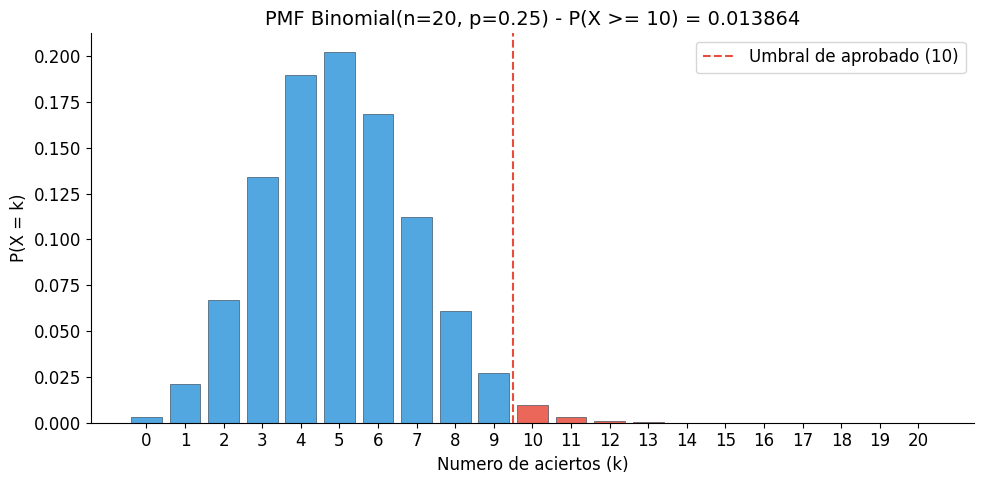

In [2]:
n, p = 20, 0.25
X = stats.binom(n, p)

prob_aprobar = 1 - X.cdf(9)
print(f"P(X >= 10) = 1 - P(X <= 9) = 1 - {X.cdf(9):.6f} = {prob_aprobar:.6f}")
print(f"La probabilidad de aprobar al azar es {prob_aprobar*100:.4f}%")

# Grafica PMF con area sombreada
k_vals = np.arange(0, n + 1)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k >= 10 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de aciertos (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Binomial(n={n}, p={p}) - P(X >= 10) = {prob_aprobar:.6f}')
ax.set_xticks(k_vals)
ax.axvline(x=9.5, color=C_DANGER, linestyle='--', linewidth=1.5, label='Umbral de aprobado (10)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 2:** Una centralita telefonica recibe en promedio 4 llamadas por hora. Cual es la probabilidad de recibir mas de 6 llamadas en una hora?

**Resolucion:**

La variable X = "numero de llamadas en una hora" sigue una distribucion **Poisson** con parametro:
- **lambda = 4** (tasa media de llamadas por hora)

**Formula:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

Queremos $P(X > 6) = 1 - P(X \leq 6)$

**Calculo paso a paso:**

$$P(X \leq 6) = \sum_{k=0}^{6} \frac{e^{-4} \cdot 4^k}{k!}$$

$$= e^{-4}\left(\frac{4^0}{0!} + \frac{4^1}{1!} + \frac{4^2}{2!} + \frac{4^3}{3!} + \frac{4^4}{4!} + \frac{4^5}{5!} + \frac{4^6}{6!}\right)$$

$$= e^{-4}(1 + 4 + 8 + 10.667 + 10.667 + 8.533 + 5.689)$$

$$= 0.01832 \times 48.556 = 0.8893$$

$$P(X > 6) = 1 - 0.8893 = 0.1107$$

P(X > 6) = 1 - P(X <= 6) = 1 - 0.889326 = 0.110674
La probabilidad de recibir mas de 6 llamadas es 11.07%


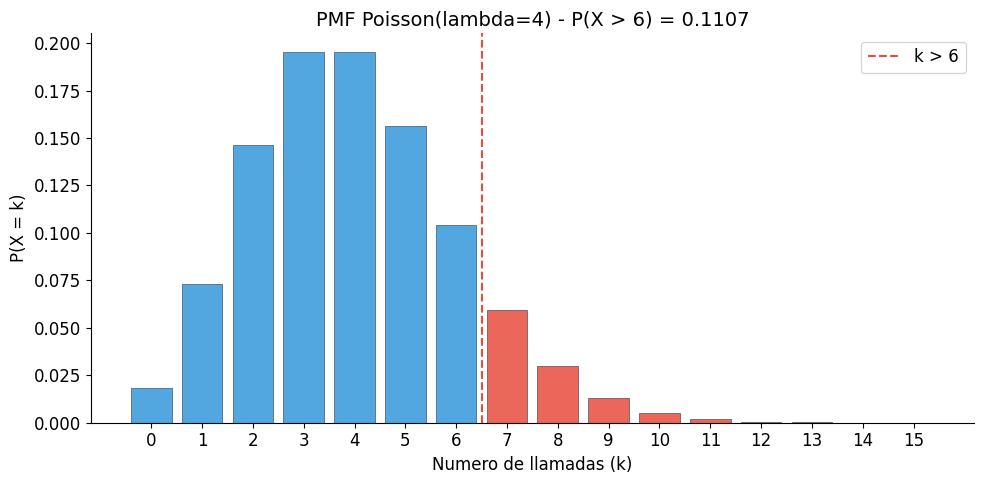

In [3]:
lam = 4
X = stats.poisson(lam)

prob = 1 - X.cdf(6)
print(f"P(X > 6) = 1 - P(X <= 6) = 1 - {X.cdf(6):.6f} = {prob:.6f}")
print(f"La probabilidad de recibir mas de 6 llamadas es {prob*100:.2f}%")

# Grafica PMF con area sombreada
k_vals = np.arange(0, 16)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k > 6 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de llamadas (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Poisson(lambda={lam}) - P(X > 6) = {prob:.4f}')
ax.set_xticks(k_vals)
ax.axvline(x=6.5, color=C_DANGER, linestyle='--', linewidth=1.5, label='k > 6')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3:** Un jugador de baloncesto tiene una probabilidad de 0.7 de encestar un tiro libre. Cual es la probabilidad de que su primer enceste sea en el 4to intento?

**Resolucion:**

La variable X = "numero de intento en el que ocurre el primer enceste" sigue una distribucion **Geometrica** con parametro:
- **p = 0.7** (probabilidad de exito en cada intento)

**Formula:** $P(X = k) = (1 - p)^{k-1} \cdot p$

donde k es el numero de intento en el que se consigue el primer exito.

**Calculo paso a paso:**

$$P(X = 4) = (1 - 0.7)^{4-1} \cdot 0.7$$
$$= (0.3)^3 \cdot 0.7$$
$$= 0.027 \cdot 0.7$$
$$= 0.0189$$

La probabilidad es 1.89%.

P(X = 4) = (1 - 0.7)^3 * 0.7 = 0.0270 * 0.7 = 0.0189
La probabilidad de que el primer enceste sea en el 4to intento es 1.89%


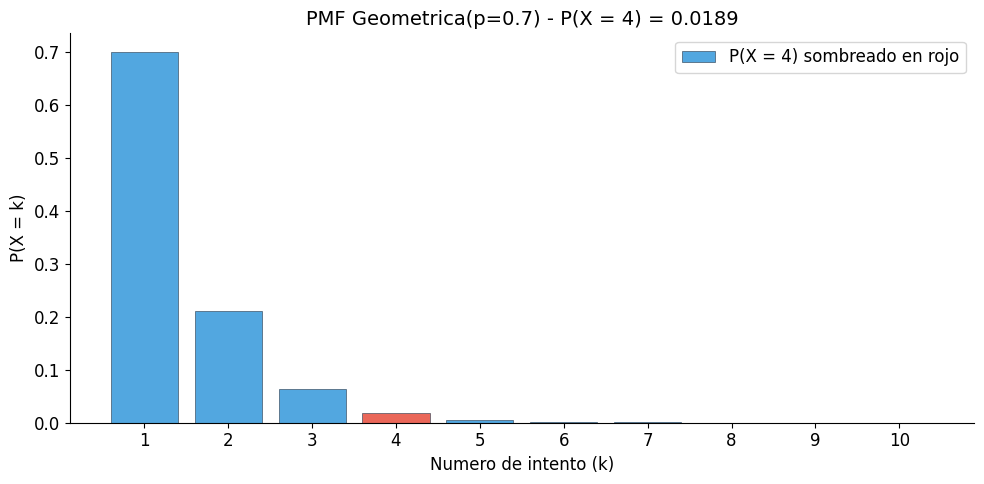

In [4]:
p = 0.7
# scipy.stats.geom usa la convencion donde k=1 es el primer intento
X = stats.geom(p)

prob = X.pmf(4)
print(f"P(X = 4) = (1 - {p})^3 * {p} = {(1-p)**3:.4f} * {p} = {prob:.4f}")
print(f"La probabilidad de que el primer enceste sea en el 4to intento es {prob*100:.2f}%")

# Grafica PMF
k_vals = np.arange(1, 11)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k == 4 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de intento (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Geometrica(p={p}) - P(X = 4) = {prob:.4f}')
ax.set_xticks(k_vals)
ax.legend(['P(X = 4) sombreado en rojo'], loc='upper right')
plt.tight_layout()
plt.show()

**Ejercicio 4:** De una baraja de 52 cartas se reparten 5. Cual es la probabilidad de obtener exactamente 2 ases?

**Resolucion:**

La variable X = "numero de ases en la mano de 5 cartas" sigue una distribucion **Hipergeometrica** con parametros:
- **N = 52** (tamano total de la poblacion, cartas en la baraja)
- **K = 4** (numero de exitos en la poblacion, ases en la baraja)
- **n = 5** (tamano de la muestra, cartas repartidas)

**Formula:** $P(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}$

**Calculo paso a paso:**

$$P(X = 2) = \frac{\binom{4}{2} \binom{48}{3}}{\binom{52}{5}}$$

$$= \frac{6 \times 17296}{2598960}$$

$$= \frac{103776}{2598960}$$

$$= 0.03993$$

La probabilidad es aproximadamente 3.99%.

C(4,2) = 6
C(48,3) = 17296
C(52,5) = 2598960
P(X = 2) = 6 * 17296 / 2598960 = 0.03993
La probabilidad de obtener exactamente 2 ases es 3.99%


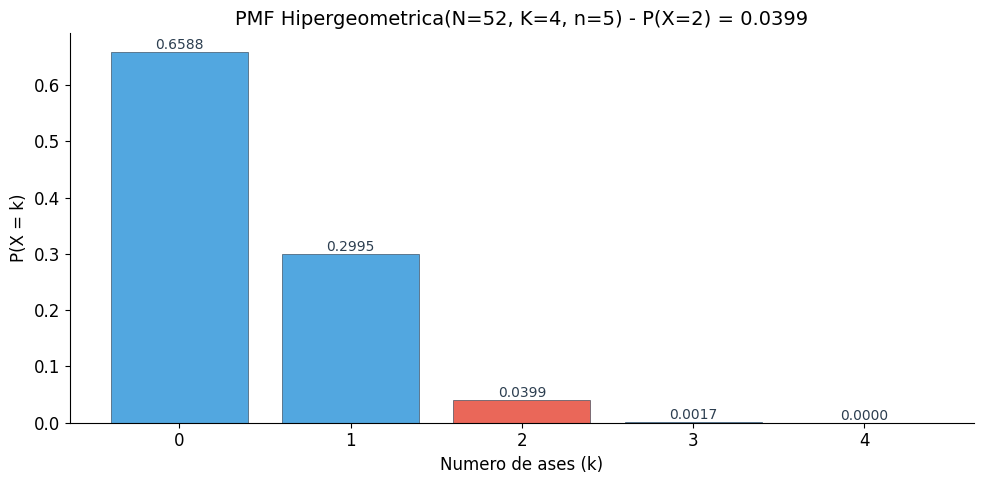

In [5]:
N_total, K_ases, n_mano = 52, 4, 5
# scipy hypergeom: M=N_total, n=K_ases, N=n_mano
X = stats.hypergeom(N_total, K_ases, n_mano)

prob = X.pmf(2)
print(f"C(4,2) = {int(comb(4, 2))}")
print(f"C(48,3) = {int(comb(48, 3))}")
print(f"C(52,5) = {int(comb(52, 5))}")
print(f"P(X = 2) = {int(comb(4,2))} * {int(comb(48,3))} / {int(comb(52,5))} = {prob:.5f}")
print(f"La probabilidad de obtener exactamente 2 ases es {prob*100:.2f}%")

# Grafica PMF
k_vals = np.arange(0, 5)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k == 2 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de ases (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Hipergeometrica(N={N_total}, K={K_ases}, n={n_mano}) - P(X=2) = {prob:.4f}')
ax.set_xticks(k_vals)

for k, pmf in zip(k_vals, pmf_vals):
    ax.text(k, pmf + 0.005, f'{pmf:.4f}', ha='center', fontsize=10, color=C_DARK)

plt.tight_layout()
plt.show()

**Ejercicio 5:** Un vendedor cierra una venta con probabilidad 0.3 en cada visita. Cual es la probabilidad de que la 5ta visita sea la que consiga su 3ra venta cerrada?

**Resolucion:**

La variable X = "numero de visita en la que se consigue la r-esima venta" sigue una distribucion **Binomial Negativa** con parametros:
- **r = 3** (numero de exitos deseados)
- **p = 0.3** (probabilidad de exito en cada ensayo)

**Formula:** $P(X = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$

donde k es el numero total de ensayos necesarios para obtener r exitos.

**Calculo paso a paso:**

$$P(X = 5) = \binom{5-1}{3-1} (0.3)^3 (0.7)^{5-3}$$
$$= \binom{4}{2} (0.3)^3 (0.7)^2$$
$$= 6 \times 0.027 \times 0.49$$
$$= 6 \times 0.01323$$
$$= 0.07938$$

La probabilidad es aproximadamente 7.94%.

Calculo manual: C(4,2) * 0.3^3 * 0.7^2 = 6 * 0.0270 * 0.4900 = 0.07938
Calculo scipy:  nbinom.pmf(2, 3, 0.3) = 0.07938
La probabilidad es 7.94%


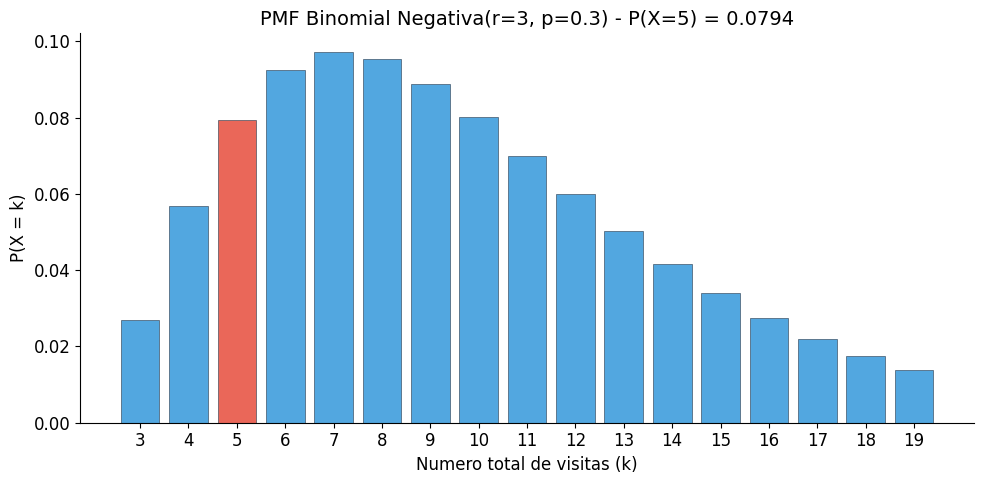

In [6]:
r, p = 3, 0.3

# scipy.stats.nbinom parametriza como numero de FRACASOS antes del r-esimo exito
# P(X=5) en nuestra convencion = P(Y=2) en scipy donde Y = num fracasos = 5 - 3 = 2
prob_manual = comb(4, 2) * p**3 * (1-p)**2
prob_scipy = stats.nbinom.pmf(2, r, p)  # k=2 fracasos, r=3 exitos

print(f"Calculo manual: C(4,2) * 0.3^3 * 0.7^2 = {comb(4,2):.0f} * {p**3:.4f} * {(1-p)**2:.4f} = {prob_manual:.5f}")
print(f"Calculo scipy:  nbinom.pmf(2, 3, 0.3) = {prob_scipy:.5f}")
print(f"La probabilidad es {prob_manual*100:.2f}%")

# Grafica PMF (en termino de numero total de visitas k = r, r+1, ...)
k_total = np.arange(r, 20)
k_fracasos = k_total - r
pmf_vals = stats.nbinom.pmf(k_fracasos, r, p)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k == 5 else C_PRIMARY for k in k_total]
ax.bar(k_total, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero total de visitas (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Binomial Negativa(r={r}, p={p}) - P(X=5) = {prob_manual:.4f}')
ax.set_xticks(k_total)
plt.tight_layout()
plt.show()

**Ejercicio 6:** Un servidor web recibe en promedio 100 visitas por minuto. Cual es la probabilidad de recibir menos de 90 visitas en un minuto?

**Resolucion:**

La variable X = "numero de visitas en un minuto" sigue una distribucion **Poisson** con parametro:
- **lambda = 100** (tasa media de visitas por minuto)

**Formula:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

Queremos $P(X < 90) = P(X \leq 89)$

**Calculo paso a paso:**

$$P(X \leq 89) = \sum_{k=0}^{89} \frac{e^{-100} \cdot 100^k}{k!}$$

Para lambda grande, la Poisson se aproxima a una Normal: $X \approx N(\lambda, \lambda)$

$$Z = \frac{89.5 - 100}{\sqrt{100}} = \frac{-10.5}{10} = -1.05$$

$$P(X < 90) \approx \Phi(-1.05) \approx 0.1469$$

Usaremos la CDF exacta de Poisson para el calculo preciso.

P(X < 90) = P(X <= 89)
  Calculo exacto (Poisson CDF):      0.146346
  Aproximacion Normal (con corr.):    0.146859
La probabilidad de recibir menos de 90 visitas es 14.63%


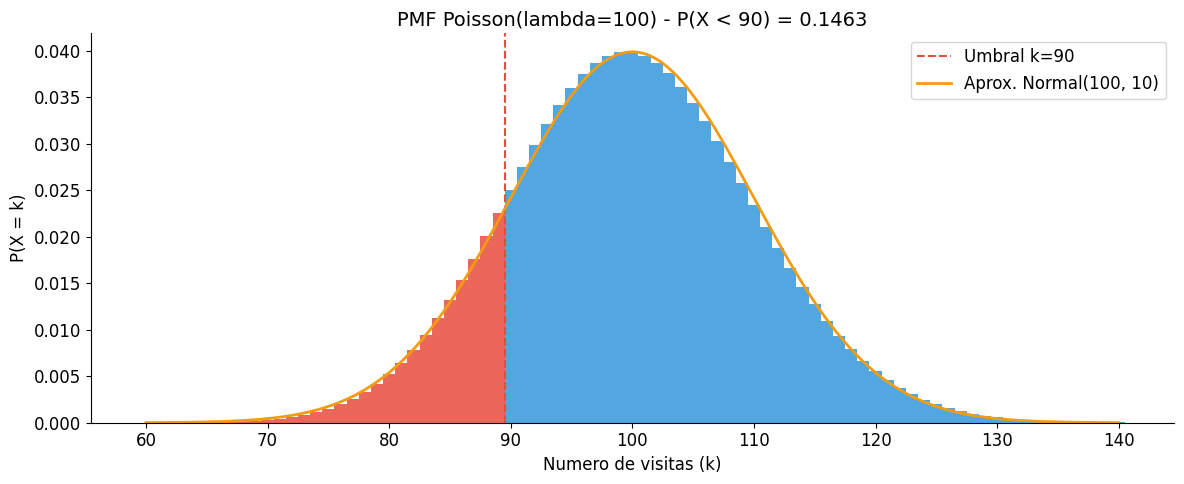

In [7]:
lam = 100
X = stats.poisson(lam)

prob_exacta = X.cdf(89)
prob_normal_aprox = stats.norm.cdf(89.5, loc=lam, scale=np.sqrt(lam))

print(f"P(X < 90) = P(X <= 89)")
print(f"  Calculo exacto (Poisson CDF):      {prob_exacta:.6f}")
print(f"  Aproximacion Normal (con corr.):    {prob_normal_aprox:.6f}")
print(f"La probabilidad de recibir menos de 90 visitas es {prob_exacta*100:.2f}%")

# Grafica PMF con area sombreada
k_vals = np.arange(60, 141)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(12, 5))
colores = [C_DANGER if k < 90 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor='none', alpha=0.85, width=1.0)
ax.set_xlabel('Numero de visitas (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Poisson(lambda={lam}) - P(X < 90) = {prob_exacta:.4f}')
ax.axvline(x=89.5, color=C_DANGER, linestyle='--', linewidth=1.5, label='Umbral k=90')

# Superponer la aproximacion Normal
x_cont = np.linspace(60, 140, 300)
pdf_normal = stats.norm.pdf(x_cont, loc=lam, scale=np.sqrt(lam))
ax.plot(x_cont, pdf_normal, color=C_ORANGE, linewidth=2, label=f'Aprox. Normal(100, 10)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 7:** Comparar las funciones de masa de probabilidad de dos distribuciones binomiales: Bin(20, 0.3) y Bin(20, 0.7). Graficar ambas side-by-side y comentar la relacion de simetria.

**Resolucion:**

Si $X \sim \text{Bin}(n, p)$, entonces $n - X \sim \text{Bin}(n, 1-p)$. Esto implica que la PMF de Bin(20, 0.3) es el reflejo (espejo) de la PMF de Bin(20, 0.7) respecto a k = 10.

**Propiedades a comparar:**

| | Bin(20, 0.3) | Bin(20, 0.7) |
|---|---|---|
| E[X] | n*p = 6 | n*p = 14 |
| Var(X) | n*p*(1-p) = 4.2 | n*p*(1-p) = 4.2 |
| Sesgo | Positivo (cola derecha) | Negativo (cola izquierda) |

Notar que la varianza es identica en ambos casos.

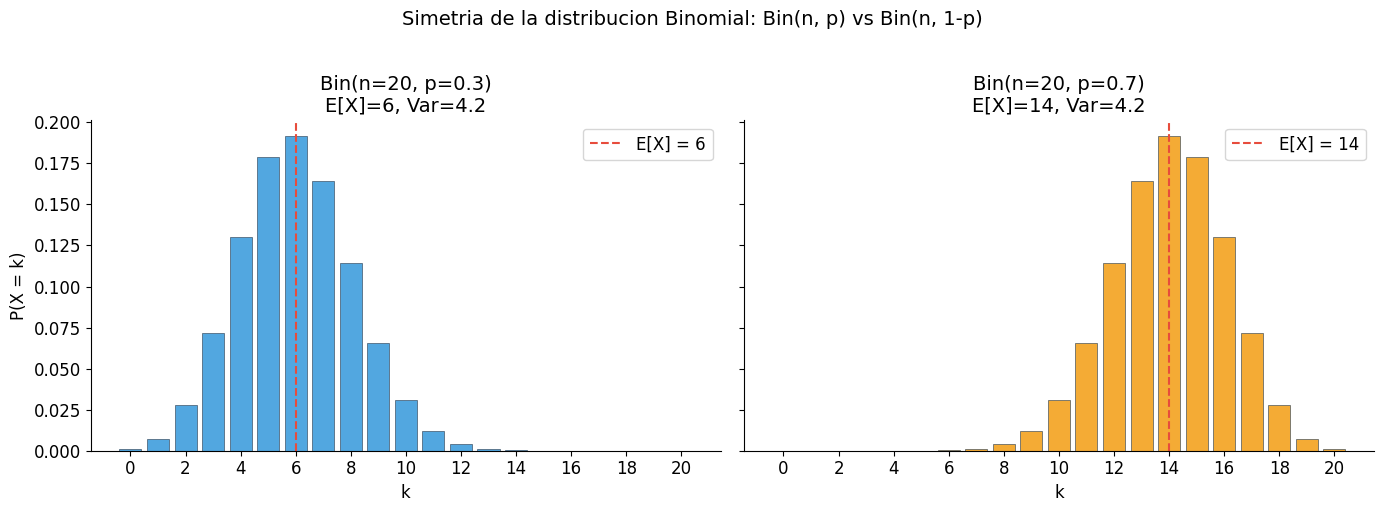

Verificacion de simetria: P_Bin(20,0.3)(X=k) == P_Bin(20,0.7)(X=20-k)
  P(X=0) con p=0.3: 0.000798  |  P(X=20) con p=0.7: 0.000798
  P(X=1) con p=0.3: 0.006839  |  P(X=19) con p=0.7: 0.006839
  P(X=2) con p=0.3: 0.027846  |  P(X=18) con p=0.7: 0.027846
  P(X=3) con p=0.3: 0.071604  |  P(X=17) con p=0.7: 0.071604
  P(X=4) con p=0.3: 0.130421  |  P(X=16) con p=0.7: 0.130421
  P(X=5) con p=0.3: 0.178863  |  P(X=15) con p=0.7: 0.178863


In [8]:
n = 20
p1, p2 = 0.3, 0.7
k_vals = np.arange(0, n + 1)

X1 = stats.binom(n, p1)
X2 = stats.binom(n, p2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.bar(k_vals, X1.pmf(k_vals), color=C_PRIMARY, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax1.set_title(f'Bin(n={n}, p={p1})\nE[X]={n*p1:.0f}, Var={n*p1*(1-p1):.1f}')
ax1.set_xlabel('k')
ax1.set_ylabel('P(X = k)')
ax1.set_xticks(k_vals[::2])
ax1.axvline(x=n*p1, color=C_DANGER, linestyle='--', linewidth=1.5, label=f'E[X] = {n*p1:.0f}')
ax1.legend()

ax2.bar(k_vals, X2.pmf(k_vals), color=C_ORANGE, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax2.set_title(f'Bin(n={n}, p={p2})\nE[X]={n*p2:.0f}, Var={n*p2*(1-p2):.1f}')
ax2.set_xlabel('k')
ax2.set_xticks(k_vals[::2])
ax2.axvline(x=n*p2, color=C_DANGER, linestyle='--', linewidth=1.5, label=f'E[X] = {n*p2:.0f}')
ax2.legend()

fig.suptitle('Simetria de la distribucion Binomial: Bin(n, p) vs Bin(n, 1-p)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Verificar simetria numericamente
print("Verificacion de simetria: P_Bin(20,0.3)(X=k) == P_Bin(20,0.7)(X=20-k)")
for k in range(6):
    print(f"  P(X={k}) con p=0.3: {X1.pmf(k):.6f}  |  P(X={20-k}) con p=0.7: {X2.pmf(20-k):.6f}")

**Ejercicio 8:** Para cada una de las distribuciones discretas estudiadas (Bernoulli, Binomial, Geometrica, Poisson, Hipergeometrica), calcular la esperanza E[X] y la varianza Var(X), graficar la PMF y construir una tabla resumen.

**Resolucion:**

Tabla de formulas teoricas:

| Distribucion | Parametros | E[X] | Var(X) |
|---|---|---|---|
| Bernoulli | p | p | p(1-p) |
| Binomial | n, p | np | np(1-p) |
| Geometrica | p | 1/p | (1-p)/p^2 |
| Poisson | lambda | lambda | lambda |
| Hipergeometrica | N, K, n | nK/N | nK(N-K)(N-n) / (N^2(N-1)) |

Se verificara cada formula numericamente con scipy.stats y se graficara la PMF de cada una.

Distribucion                     E[X] teorica     E[X] scipy   Var(X) teorica   Var(X) scipy
--------------------------------------------------------------------------------------------
Bernoulli (p=0.6)                      0.6000         0.6000           0.2400         0.2400
Binomial (n=15, p=0.4)                 6.0000         6.0000           3.6000         3.6000
Geometrica (p=0.3)                     3.3333         3.3333           7.7778         7.7778
Poisson (lambda=5)                     5.0000         5.0000           5.0000         5.0000
Hipergeom. (N=50,K=10,n=8)             1.6000         1.6000           1.0971         1.0971


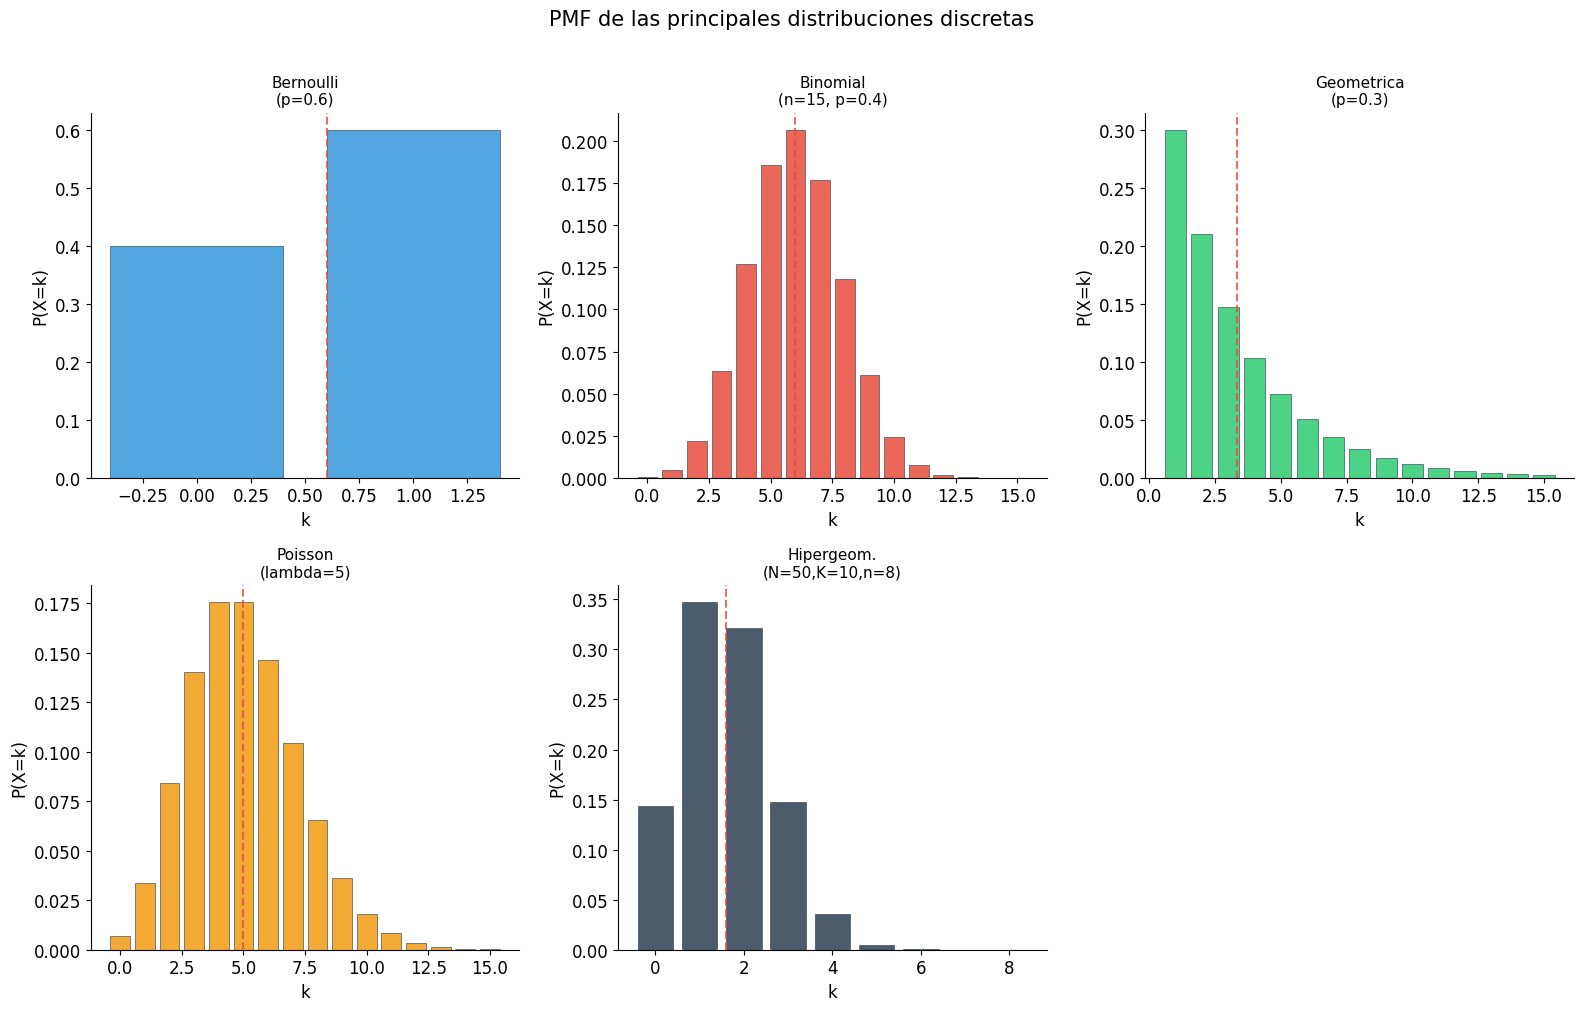

In [9]:
# Definir distribuciones con parametros representativos
distribuciones = {
    'Bernoulli\n(p=0.6)': {
        'dist': stats.bernoulli(0.6),
        'k_range': np.arange(0, 2),
        'E_formula': 0.6,
        'V_formula': 0.6 * 0.4,
    },
    'Binomial\n(n=15, p=0.4)': {
        'dist': stats.binom(15, 0.4),
        'k_range': np.arange(0, 16),
        'E_formula': 15 * 0.4,
        'V_formula': 15 * 0.4 * 0.6,
    },
    'Geometrica\n(p=0.3)': {
        'dist': stats.geom(0.3),
        'k_range': np.arange(1, 16),
        'E_formula': 1 / 0.3,
        'V_formula': 0.7 / 0.3**2,
    },
    'Poisson\n(lambda=5)': {
        'dist': stats.poisson(5),
        'k_range': np.arange(0, 16),
        'E_formula': 5,
        'V_formula': 5,
    },
    'Hipergeom.\n(N=50,K=10,n=8)': {
        'dist': stats.hypergeom(50, 10, 8),
        'k_range': np.arange(0, 9),
        'E_formula': 8 * 10 / 50,
        'V_formula': 8 * 10 * 40 * 42 / (50**2 * 49),
    },
}

colors = [C_PRIMARY, C_DANGER, C_SUCCESS, C_ORANGE, C_DARK]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

print(f"{'Distribucion':<30} {'E[X] teorica':>14} {'E[X] scipy':>14} {'Var(X) teorica':>16} {'Var(X) scipy':>14}")
print("-" * 92)

for i, (nombre, info) in enumerate(distribuciones.items()):
    dist = info['dist']
    k = info['k_range']
    pmf = dist.pmf(k)
    media, var = dist.mean(), dist.var()

    nombre_limpio = nombre.replace('\n', ' ')
    print(f"{nombre_limpio:<30} {info['E_formula']:>14.4f} {media:>14.4f} {info['V_formula']:>16.4f} {var:>14.4f}")

    ax = axes[i]
    ax.bar(k, pmf, color=colors[i], edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)')
    ax.axvline(x=media, color=C_DANGER, linestyle='--', linewidth=1.5, alpha=0.8)

# Ocultar el subplot sobrante
axes[5].set_visible(False)

fig.suptitle('PMF de las principales distribuciones discretas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Ejercicio 9:** Una vacuna tiene una eficacia del 85%. Si se vacunan 20 personas, cual es la probabilidad de que al menos 18 queden inmunizadas?

**Resolucion:**

La variable X = "numero de personas inmunizadas" sigue una distribucion **Binomial** con parametros:
- **n = 20**: numero de personas vacunadas (ensayos independientes)
- **p = 0.85**: probabilidad de que la vacuna sea efectiva en cada persona

**Formula:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$

- $\binom{n}{k}$: numero de formas de elegir cuales $k$ personas quedan inmunizadas
- $p^k$: probabilidad de que exactamente $k$ personas respondan a la vacuna
- $(1-p)^{n-k}$: probabilidad de que las $n-k$ restantes no respondan

Queremos $P(X \geq 18) = P(X=18) + P(X=19) + P(X=20)$

**Calculo paso a paso:**

$$P(X=18) = \binom{20}{18}(0.85)^{18}(0.15)^{2} = 190 \times 0.0536 \times 0.0225 = 0.2293$$

$$P(X=19) = \binom{20}{19}(0.85)^{19}(0.15)^{1} = 20 \times 0.0456 \times 0.15 = 0.1368$$

$$P(X=20) = \binom{20}{20}(0.85)^{20}(0.15)^{0} = 1 \times 0.0388 \times 1 = 0.0388$$

$$P(X \geq 18) = 0.2293 + 0.1368 + 0.0388 = 0.4049$$

In [ ]:
n, p = 20, 0.85
X = stats.binom(n, p)

prob = 1 - X.cdf(17)
print(f"P(X >= 18) = 1 - P(X <= 17) = 1 - {X.cdf(17):.6f} = {prob:.6f}")
print(f"Desglose:")
for k in [18, 19, 20]:
    print(f"  P(X={k}) = {X.pmf(k):.6f}")
print(f"Suma = {X.pmf(18) + X.pmf(19) + X.pmf(20):.6f}")
print(f"La probabilidad de que al menos 18 queden inmunizadas es {prob*100:.2f}%")

# Grafica PMF
k_vals = np.arange(0, n + 1)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k >= 18 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de inmunizados (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Binomial(n={n}, p={p}) - P(X >= 18) = {prob:.4f}')
ax.set_xticks(k_vals)
ax.axvline(x=17.5, color=C_DANGER, linestyle='--', linewidth=1.5, label='Umbral k=18')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 10:** Un hospital atiende en promedio 5 urgencias por hora. Cual es la probabilidad de atender mas de 8 urgencias en una hora? Y la probabilidad de atender menos de 3?

**Resolucion:**

La variable X = "numero de urgencias atendidas en una hora" sigue una distribucion **Poisson** con parametro:
- **lambda = 5**: tasa media de urgencias por hora

**Formula:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

- $k$: numero de urgencias observadas en la hora
- $\lambda = 5$: numero esperado de urgencias por hora
- $e^{-\lambda}$: factor de normalizacion que asegura que las probabilidades sumen 1
- $k!$: factorial de $k$, aparece porque los eventos son indistinguibles en orden

**Parte 1:** $P(X > 8) = 1 - P(X \leq 8)$

$$P(X \leq 8) = \sum_{k=0}^{8} \frac{e^{-5} \cdot 5^k}{k!}$$

**Parte 2:** $P(X < 3) = P(X \leq 2) = P(X=0) + P(X=1) + P(X=2)$

$$= e^{-5}\left(\frac{5^0}{0!} + \frac{5^1}{1!} + \frac{5^2}{2!}\right) = e^{-5}(1 + 5 + 12.5) = 0.006738 \times 18.5 = 0.1247$$

In [ ]:
lam = 5
X = stats.poisson(lam)

prob_mas_8 = 1 - X.cdf(8)
prob_menos_3 = X.cdf(2)

print(f"P(X > 8) = 1 - P(X <= 8) = 1 - {X.cdf(8):.6f} = {prob_mas_8:.6f}")
print(f"P(X < 3) = P(X <= 2) = {prob_menos_3:.6f}")
print(f"\nLa probabilidad de mas de 8 urgencias es {prob_mas_8*100:.2f}%")
print(f"La probabilidad de menos de 3 urgencias es {prob_menos_3*100:.2f}%")

# Grafica PMF con ambas areas sombreadas
k_vals = np.arange(0, 18)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = []
for k in k_vals:
    if k > 8:
        colores.append(C_DANGER)
    elif k < 3:
        colores.append(C_ORANGE)
    else:
        colores.append(C_PRIMARY)
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de urgencias (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Poisson(lambda={lam}) - P(X>8)={prob_mas_8:.4f}, P(X<3)={prob_menos_3:.4f}')
ax.set_xticks(k_vals)
ax.axvline(x=8.5, color=C_DANGER, linestyle='--', linewidth=1.5, label=f'P(X>8) = {prob_mas_8:.4f}')
ax.axvline(x=2.5, color=C_ORANGE, linestyle='--', linewidth=1.5, label=f'P(X<3) = {prob_menos_3:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 11:** Un jugador de baloncesto encesta con probabilidad 0.4. Cual es la probabilidad de que necesite mas de 5 tiros para conseguir su primer enceste? Cual es la esperanza del numero de intentos?

**Resolucion:**

La variable X = "numero de tiro en el que se consigue el primer enceste" sigue una distribucion **Geometrica** con parametro:
- **p = 0.4**: probabilidad de encestar en cada tiro

**Formula:** $P(X = k) = (1-p)^{k-1} \cdot p$

- $k$: numero de tiro en el que ocurre el primer exito ($k = 1, 2, 3, \ldots$)
- $(1-p)^{k-1}$: probabilidad de fallar los primeros $k-1$ tiros
- $p$: probabilidad de encestar en el tiro $k$-esimo

**Probabilidad de necesitar mas de 5 tiros:**

$P(X > 5)$ significa que los primeros 5 tiros fueron fallos:

$$P(X > 5) = (1-p)^5 = (0.6)^5 = 0.07776$$

**Esperanza:**

$$E[X] = \frac{1}{p} = \frac{1}{0.4} = 2.5 \text{ intentos}$$

In [ ]:
p = 0.4
X = stats.geom(p)

prob_mas_5 = 1 - X.cdf(5)
esperanza = X.mean()

print(f"P(X > 5) = (1 - {p})^5 = {(1-p)**5:.5f}")
print(f"P(X > 5) via CDF = 1 - P(X <= 5) = 1 - {X.cdf(5):.6f} = {prob_mas_5:.5f}")
print(f"E[X] = 1/p = 1/{p} = {esperanza:.2f} intentos")

# Grafica PMF
k_vals = np.arange(1, 16)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k > 5 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de intento (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Geometrica(p={p}) - P(X > 5) = {prob_mas_5:.5f}, E[X] = {esperanza:.1f}')
ax.set_xticks(k_vals)
ax.axvline(x=5.5, color=C_DANGER, linestyle='--', linewidth=1.5, label='Umbral k > 5')
ax.axvline(x=esperanza, color=C_SUCCESS, linestyle='--', linewidth=1.5, label=f'E[X] = {esperanza:.1f}')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 12:** Un lote contiene 100 piezas, de las cuales 10 son defectuosas. Se inspeccionan 15 piezas al azar sin reemplazo. Cual es la probabilidad de encontrar exactamente 2 defectuosas?

**Resolucion:**

La variable X = "numero de piezas defectuosas en la muestra" sigue una distribucion **Hipergeometrica** con parametros:
- **N = 100**: tamano total del lote (poblacion)
- **K = 10**: numero de piezas defectuosas en el lote (exitos en la poblacion)
- **n = 15**: tamano de la muestra inspeccionada

**Formula:** $P(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}$

- $\binom{K}{k} = \binom{10}{2}$: formas de elegir 2 defectuosas entre las 10 existentes
- $\binom{N-K}{n-k} = \binom{90}{13}$: formas de elegir 13 piezas buenas entre las 90 disponibles
- $\binom{N}{n} = \binom{100}{15}$: formas totales de elegir 15 piezas del lote

**Calculo:**

$$P(X = 2) = \frac{\binom{10}{2} \binom{90}{13}}{\binom{100}{15}} = \frac{45 \times \binom{90}{13}}{\binom{100}{15}}$$

In [ ]:
N_total, K_def, n_muestra = 100, 10, 15
X = stats.hypergeom(N_total, K_def, n_muestra)

prob = X.pmf(2)
print(f"C(10,2) = {int(comb(10, 2))}")
print(f"C(90,13) = {int(comb(90, 13))}")
print(f"C(100,15) = {int(comb(100, 15))}")
print(f"P(X = 2) = {prob:.6f}")
print(f"La probabilidad de encontrar exactamente 2 defectuosas es {prob*100:.2f}%")
print(f"\nE[X] = n*K/N = {n_muestra}*{K_def}/{N_total} = {n_muestra*K_def/N_total:.2f}")

# Grafica PMF
k_vals = np.arange(0, min(K_def, n_muestra) + 1)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k == 2 else C_PRIMARY for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de defectuosas (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Hipergeometrica(N={N_total}, K={K_def}, n={n_muestra}) - P(X=2) = {prob:.4f}')
ax.set_xticks(k_vals)

for k, pmf in zip(k_vals, pmf_vals):
    if pmf > 0.005:
        ax.text(k, pmf + 0.005, f'{pmf:.4f}', ha='center', fontsize=9, color=C_DARK)

plt.tight_layout()
plt.show()

**Ejercicio 13:** Un repartidor entrega paquetes con exito con probabilidad 0.8. Cual es la probabilidad de que la 10ma entrega exitosa ocurra en la 13va entrega?

**Resolucion:**

La variable X = "numero de entrega en la que se consigue el r-esimo exito" sigue una distribucion **Binomial Negativa** con parametros:
- **r = 10**: numero de entregas exitosas deseadas
- **p = 0.8**: probabilidad de exito en cada entrega

**Formula:** $P(X = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$

- $k = 13$: numero total de entregas realizadas
- $r = 10$: el exito numero 10 debe ocurrir exactamente en la entrega 13
- $\binom{k-1}{r-1} = \binom{12}{9}$: formas de distribuir 9 exitos en las primeras 12 entregas (la 13va es forzosamente exito)
- $p^r = (0.8)^{10}$: probabilidad de los 10 exitos
- $(1-p)^{k-r} = (0.2)^3$: probabilidad de los 3 fracasos

**Calculo:**

$$P(X = 13) = \binom{12}{9} (0.8)^{10} (0.2)^3$$
$$= 220 \times 0.10737 \times 0.008$$
$$= 220 \times 0.000859$$
$$= 0.1889$$

In [ ]:
r, p = 10, 0.8

# Calculo manual
prob_manual = comb(12, 9) * p**10 * (1-p)**3
# scipy: nbinom parametriza como numero de fracasos antes del r-esimo exito
# k_total=13, fracasos = 13 - 10 = 3
prob_scipy = stats.nbinom.pmf(3, r, p)

print(f"Calculo manual: C(12,9) * 0.8^10 * 0.2^3")
print(f"  = {int(comb(12,9))} * {p**10:.5f} * {(1-p)**3:.5f} = {prob_manual:.6f}")
print(f"Calculo scipy:  nbinom.pmf(3, 10, 0.8) = {prob_scipy:.6f}")
print(f"La probabilidad es {prob_manual*100:.2f}%")
print(f"\nE[X] = r/p = {r}/{p} = {r/p:.2f} entregas")

# Grafica PMF (en termino de numero total de entregas)
k_total = np.arange(r, 25)
k_fracasos = k_total - r
pmf_vals = stats.nbinom.pmf(k_fracasos, r, p)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [C_DANGER if k == 13 else C_PRIMARY for k in k_total]
ax.bar(k_total, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero total de entregas (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Binomial Negativa(r={r}, p={p}) - P(X=13) = {prob_manual:.4f}')
ax.set_xticks(k_total)
ax.axvline(x=r/p, color=C_SUCCESS, linestyle='--', linewidth=1.5, label=f'E[X] = {r/p:.1f}')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 14:** En un libro se encuentran en promedio 2 errores tipograficos por pagina. Cual es la probabilidad de que una pagina no tenga errores? Y la probabilidad de que tenga mas de 4?

**Resolucion:**

La variable X = "numero de errores tipograficos por pagina" sigue una distribucion **Poisson** con parametro:
- **lambda = 2**: tasa media de errores por pagina

**Formula:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

- $k$: numero de errores observados en una pagina
- $\lambda = 2$: numero esperado de errores por pagina
- $e^{-\lambda} = e^{-2} \approx 0.1353$: factor de normalizacion

**Parte 1 - Pagina sin errores:**

$$P(X = 0) = \frac{e^{-2} \cdot 2^0}{0!} = e^{-2} = 0.1353$$

**Parte 2 - Mas de 4 errores:**

$$P(X > 4) = 1 - P(X \leq 4) = 1 - \sum_{k=0}^{4} \frac{e^{-2} \cdot 2^k}{k!}$$

$$= 1 - e^{-2}\left(1 + 2 + 2 + \frac{4}{3} + \frac{2}{3}\right) = 1 - e^{-2} \times 7 = 1 - 0.9473 = 0.0527$$

In [ ]:
lam = 2
X = stats.poisson(lam)

prob_cero = X.pmf(0)
prob_mas_4 = 1 - X.cdf(4)

print(f"P(X = 0) = e^(-2) = {prob_cero:.6f}")
print(f"P(X > 4) = 1 - P(X <= 4) = 1 - {X.cdf(4):.6f} = {prob_mas_4:.6f}")
print(f"\nProbabilidad de pagina sin errores: {prob_cero*100:.2f}%")
print(f"Probabilidad de mas de 4 errores: {prob_mas_4*100:.2f}%")

# Grafica PMF
k_vals = np.arange(0, 12)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = []
for k in k_vals:
    if k == 0:
        colores.append(C_SUCCESS)
    elif k > 4:
        colores.append(C_DANGER)
    else:
        colores.append(C_PRIMARY)
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de errores (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Poisson(lambda={lam}) - P(X=0)={prob_cero:.4f}, P(X>4)={prob_mas_4:.4f}')
ax.set_xticks(k_vals)

for k, pmf in zip(k_vals, pmf_vals):
    if pmf > 0.005:
        ax.text(k, pmf + 0.005, f'{pmf:.4f}', ha='center', fontsize=9, color=C_DARK)

plt.tight_layout()
plt.show()

**Ejercicio 15:** En un proceso de control de calidad, la probabilidad de que un articulo sea defectuoso es p=0.05. Se inspecciona un lote de 100 articulos. Calcular P(X<=3), P(X=0) y E[X].

**Resolucion:**

La variable X = "numero de articulos defectuosos en el lote" sigue una distribucion **Binomial** con parametros:
- **n = 100**: numero de articulos inspeccionados (ensayos independientes)
- **p = 0.05**: probabilidad de que un articulo sea defectuoso

**Formula:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$

- $\binom{n}{k}$: formas de elegir cuales $k$ articulos resultan defectuosos
- $p^k = (0.05)^k$: probabilidad de que $k$ articulos sean defectuosos
- $(1-p)^{n-k} = (0.95)^{n-k}$: probabilidad de que los restantes sean buenos

**P(X = 0):**

$$P(X = 0) = \binom{100}{0}(0.05)^0(0.95)^{100} = (0.95)^{100} \approx 0.00592$$

**P(X <= 3):**

$$P(X \leq 3) = \sum_{k=0}^{3} \binom{100}{k}(0.05)^k(0.95)^{100-k}$$

**Esperanza:**

$$E[X] = np = 100 \times 0.05 = 5 \text{ articulos defectuosos}$$

In [ ]:
n, p = 100, 0.05
X = stats.binom(n, p)

prob_0 = X.pmf(0)
prob_leq3 = X.cdf(3)
esperanza = X.mean()

print(f"P(X = 0) = (0.95)^100 = {prob_0:.6f}")
print(f"P(X <= 3) = {prob_leq3:.6f}")
print(f"  Desglose:")
for k in range(4):
    print(f"    P(X={k}) = {X.pmf(k):.6f}")
print(f"E[X] = n*p = {n}*{p} = {esperanza:.1f}")
print(f"Var(X) = n*p*(1-p) = {n*p*(1-p):.2f}")

# Grafica PMF
k_vals = np.arange(0, 20)
pmf_vals = X.pmf(k_vals)

fig, ax = plt.subplots(figsize=(10, 5))
colores = []
for k in k_vals:
    if k == 0:
        colores.append(C_SUCCESS)
    elif k <= 3:
        colores.append(C_ORANGE)
    else:
        colores.append(C_PRIMARY)
ax.bar(k_vals, pmf_vals, color=colores, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax.set_xlabel('Numero de defectuosos (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'PMF Binomial(n={n}, p={p}) - P(X=0)={prob_0:.4f}, P(X<=3)={prob_leq3:.4f}')
ax.set_xticks(k_vals)
ax.axvline(x=esperanza, color=C_DANGER, linestyle='--', linewidth=1.5, label=f'E[X] = {esperanza:.0f}')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 16:** La distribucion Geometrica tiene la propiedad de falta de memoria (memoryless property). Demostrar que P(X > s+t | X > s) = P(X > t) con un ejemplo numerico usando p = 0.3, s = 4 y t = 3.

**Resolucion:**

La propiedad de falta de memoria establece que, para una variable $X \sim \text{Geom}(p)$:

$$P(X > s + t \mid X > s) = P(X > t)$$

- $X$: numero de ensayo en el que ocurre el primer exito
- $s$: numero de fracasos ya observados (el "pasado" que se olvida)
- $t$: numero de ensayos adicionales sin exito
- $p$: probabilidad de exito en cada ensayo

**Demostracion analitica:**

Recordemos que $P(X > k) = (1-p)^k$ (fallar los primeros $k$ ensayos).

$$P(X > s+t \mid X > s) = \frac{P(X > s+t \cap X > s)}{P(X > s)} = \frac{P(X > s+t)}{P(X > s)}$$

$$= \frac{(1-p)^{s+t}}{(1-p)^s} = (1-p)^t = P(X > t)$$

**Ejemplo numerico con p=0.3, s=4, t=3:**

$$P(X > 7 \mid X > 4) = \frac{(0.7)^7}{(0.7)^4} = (0.7)^3 = P(X > 3)$$

Esto significa que si un jugador ya fallo 4 veces, la probabilidad de necesitar al menos 3 tiros mas es la misma que si empezara de cero.

In [ ]:
p = 0.3
s, t = 4, 3
X = stats.geom(p)

# P(X > k) = 1 - P(X <= k) = (1-p)^k
p_x_gt_spt = 1 - X.cdf(s + t)   # P(X > 7)
p_x_gt_s = 1 - X.cdf(s)          # P(X > 4)
p_x_gt_t = 1 - X.cdf(t)          # P(X > 3)

# P(X > s+t | X > s) = P(X > s+t) / P(X > s)
p_condicional = p_x_gt_spt / p_x_gt_s

print("Verificacion de la propiedad de falta de memoria")
print("=" * 55)
print(f"P(X > {s+t}) = (1-{p})^{s+t} = {(1-p)**(s+t):.6f}")
print(f"P(X > {s})   = (1-{p})^{s}   = {(1-p)**s:.6f}")
print(f"P(X > {t})   = (1-{p})^{t}   = {(1-p)**t:.6f}")
print(f"\nP(X > {s+t} | X > {s}) = P(X > {s+t}) / P(X > {s})")
print(f"                      = {p_x_gt_spt:.6f} / {p_x_gt_s:.6f}")
print(f"                      = {p_condicional:.6f}")
print(f"P(X > {t})            = {p_x_gt_t:.6f}")
print(f"\nIgualdad verificada: {np.isclose(p_condicional, p_x_gt_t)}")

# Grafica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

k_vals = np.arange(1, 16)
pmf_vals = X.pmf(k_vals)

# PMF original
ax1.bar(k_vals, pmf_vals, color=C_PRIMARY, edgecolor=C_DARK, alpha=0.85, linewidth=0.5)
ax1.axvline(x=s + 0.5, color=C_DANGER, linestyle='--', linewidth=1.5, label=f's = {s}')
ax1.axvline(x=s + t + 0.5, color=C_ORANGE, linestyle='--', linewidth=1.5, label=f's+t = {s+t}')
ax1.set_title(f'PMF Geometrica(p={p})')
ax1.set_xlabel('k')
ax1.set_ylabel('P(X = k)')
ax1.set_xticks(k_vals)
ax1.legend()

# PMF condicional vs original desplazada
# P(X = s+j | X > s) deberia ser igual a P(X = j) para j = 1, 2, ...
j_vals = np.arange(1, 11)
pmf_original = X.pmf(j_vals)
pmf_condicional = X.pmf(s + j_vals) / p_x_gt_s

width = 0.35
ax2.bar(j_vals - width/2, pmf_original, width, color=C_PRIMARY, edgecolor=C_DARK, alpha=0.85, label='P(X = j) original')
ax2.bar(j_vals + width/2, pmf_condicional, width, color=C_DANGER, edgecolor=C_DARK, alpha=0.85, label=f'P(X = {s}+j | X > {s})')
ax2.set_title('Falta de memoria: ambas distribuciones coinciden')
ax2.set_xlabel('j (ensayos desde el punto de referencia)')
ax2.set_ylabel('Probabilidad')
ax2.set_xticks(j_vals)
ax2.legend()

plt.tight_layout()
plt.show()

**Ejercicio 17:** Comparar la distribucion Hipergeometrica con la Binomial cuando la poblacion es grande. Una urna contiene 1000 bolas, de las cuales 100 son rojas. Se extraen 10 bolas sin reemplazo (Hipergeometrica) y con reemplazo (Binomial). Comparar ambas distribuciones.

**Resolucion:**

Cuando la poblacion $N$ es mucho mayor que la muestra $n$ ($n/N < 0.05$ aproximadamente), la Hipergeometrica se aproxima a la Binomial con $p = K/N$.

**Hipergeometrica:**

$P(X = k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}$

- $N = 1000$: total de bolas en la urna
- $K = 100$: bolas rojas en la urna
- $n = 10$: bolas extraidas sin reemplazo
- $k$: bolas rojas observadas en la muestra

**Binomial (aproximacion):**

$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$

- $n = 10$: bolas extraidas con reemplazo
- $p = K/N = 100/1000 = 0.1$: probabilidad de extraer bola roja
- $k$: bolas rojas observadas

**Razon de la aproximacion:** cuando $n/N$ es pequeno, extraer sin reemplazo apenas cambia la composicion de la urna, y el muestreo se comporta casi como si fuera con reemplazo. En este caso, $n/N = 10/1000 = 0.01$, por lo que la aproximacion sera excelente.

In [ ]:
N_total, K_rojas, n_ext = 1000, 100, 10
p_aprox = K_rojas / N_total

X_hyper = stats.hypergeom(N_total, K_rojas, n_ext)
X_binom = stats.binom(n_ext, p_aprox)

k_vals = np.arange(0, n_ext + 1)
pmf_hyper = X_hyper.pmf(k_vals)
pmf_binom = X_binom.pmf(k_vals)

# Tabla comparativa
print(f"{'k':>3} {'Hipergeom':>12} {'Binomial':>12} {'Diferencia':>12}")
print("-" * 42)
for k in k_vals:
    if pmf_hyper[k] > 1e-6 or pmf_binom[k] > 1e-6:
        print(f"{k:>3} {pmf_hyper[k]:>12.6f} {pmf_binom[k]:>12.6f} {abs(pmf_hyper[k]-pmf_binom[k]):>12.8f}")

print(f"\nE[X] Hipergeom = {X_hyper.mean():.4f}, Binomial = {X_binom.mean():.4f}")
print(f"Var(X) Hipergeom = {X_hyper.var():.4f}, Binomial = {X_binom.var():.4f}")
print(f"Factor de correccion finita: (N-n)/(N-1) = {(N_total-n_ext)/(N_total-1):.4f}")
print(f"Var(Hyper) / Var(Binom) = {X_hyper.var()/X_binom.var():.4f}")

# Grafica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35
ax1.bar(k_vals - width/2, pmf_hyper, width, color=C_PRIMARY, edgecolor=C_DARK, alpha=0.85, label='Hipergeometrica')
ax1.bar(k_vals + width/2, pmf_binom, width, color=C_DANGER, edgecolor=C_DARK, alpha=0.85, label='Binomial')
ax1.set_xlabel('Numero de bolas rojas (k)')
ax1.set_ylabel('P(X = k)')
ax1.set_title('Comparacion PMF: Hipergeometrica vs Binomial')
ax1.set_xticks(k_vals)
ax1.legend()

# Diferencia absoluta
ax2.bar(k_vals, np.abs(pmf_hyper - pmf_binom), color=C_ORANGE, edgecolor=C_DARK, alpha=0.85)
ax2.set_xlabel('k')
ax2.set_ylabel('|P_hyper(k) - P_binom(k)|')
ax2.set_title(f'Diferencia absoluta (max = {np.max(np.abs(pmf_hyper - pmf_binom)):.6f})')
ax2.set_xticks(k_vals)

plt.tight_layout()
plt.show()

**Ejercicio 18:** Aproximacion de Poisson a la Binomial. Cuando n es grande y p es pequeno, la Binomial se aproxima a una Poisson con lambda = np. Comparar Bin(1000, 0.002) con Poisson(2).

**Resolucion:**

**Teorema de aproximacion:** Si $X \sim \text{Bin}(n, p)$ con $n \to \infty$ y $p \to 0$ de forma que $\lambda = np$ se mantiene constante, entonces:

$$\binom{n}{k} p^k (1-p)^{n-k} \xrightarrow{} \frac{e^{-\lambda} \lambda^k}{k!}$$

**Binomial:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$

- $n = 1000$: numero de ensayos (muy grande)
- $p = 0.002$: probabilidad de exito (muy pequena)
- $k$: numero de exitos observados

**Poisson (aproximacion):** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

- $\lambda = np = 1000 \times 0.002 = 2$: tasa media de exitos
- $k$: numero de exitos observados

**Regla practica:** la aproximacion es buena cuando $n \geq 20$ y $p \leq 0.05$ (o equivalentemente, $np \leq 5$).

In [ ]:
n, p = 1000, 0.002
lam = n * p

X_binom = stats.binom(n, p)
X_poisson = stats.poisson(lam)

k_vals = np.arange(0, 12)
pmf_binom = X_binom.pmf(k_vals)
pmf_poisson = X_poisson.pmf(k_vals)

# Tabla comparativa
print(f"Comparacion Bin({n}, {p}) vs Poisson({lam})")
print(f"{'k':>3} {'Binomial':>12} {'Poisson':>12} {'Diferencia':>12} {'Error rel %':>12}")
print("-" * 55)
for k in k_vals:
    diff = abs(pmf_binom[k] - pmf_poisson[k])
    err_rel = diff / pmf_binom[k] * 100 if pmf_binom[k] > 1e-10 else 0
    print(f"{k:>3} {pmf_binom[k]:>12.6f} {pmf_poisson[k]:>12.6f} {diff:>12.8f} {err_rel:>11.4f}%")

print(f"\nE[X] Binomial = {X_binom.mean():.4f}, Poisson = {X_poisson.mean():.4f}")
print(f"Var(X) Binomial = {X_binom.var():.4f}, Poisson = {X_poisson.var():.4f}")

# Grafica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35
ax1.bar(k_vals - width/2, pmf_binom, width, color=C_PRIMARY, edgecolor=C_DARK, alpha=0.85, label=f'Bin({n}, {p})')
ax1.bar(k_vals + width/2, pmf_poisson, width, color=C_DANGER, edgecolor=C_DARK, alpha=0.85, label=f'Poisson({lam})')
ax1.set_xlabel('k')
ax1.set_ylabel('P(X = k)')
ax1.set_title('Comparacion PMF: Binomial vs Poisson')
ax1.set_xticks(k_vals)
ax1.legend()

# Error relativo porcentual
err_rel = np.abs(pmf_binom - pmf_poisson) / np.where(pmf_binom > 1e-10, pmf_binom, 1) * 100
ax2.bar(k_vals, err_rel, color=C_ORANGE, edgecolor=C_DARK, alpha=0.85)
ax2.set_xlabel('k')
ax2.set_ylabel('Error relativo (%)')
ax2.set_title(f'Error relativo de la aproximacion Poisson (max = {np.max(err_rel):.4f}%)')
ax2.set_xticks(k_vals)

plt.tight_layout()
plt.show()

**Ejercicio 19:** Un dado justo de 6 caras se lanza 60 veces. Cual es la probabilidad de obtener cada cara exactamente 10 veces?

**Resolucion:**

El vector $(X_1, X_2, X_3, X_4, X_5, X_6)$ donde $X_i$ = "numero de veces que sale la cara $i$" sigue una distribucion **Multinomial** con parametros:
- **n = 60**: numero total de lanzamientos
- **k = 6**: numero de categorias (caras del dado)
- **$p_i = 1/6$** para cada $i$: probabilidad de cada cara (dado justo)

**Formula:**

$$P(X_1 = x_1, \ldots, X_k = x_k) = \frac{n!}{x_1! \cdot x_2! \cdots x_k!} \cdot p_1^{x_1} \cdot p_2^{x_2} \cdots p_k^{x_k}$$

- $n! = 60!$: permutaciones totales de los 60 lanzamientos
- $x_i! = 10!$ para cada cara: correccion por indistinguibilidad dentro de cada cara
- $\frac{n!}{x_1! \cdots x_k!}$: coeficiente multinomial, numero de formas de distribuir los lanzamientos
- $p_i^{x_i} = (1/6)^{10}$: probabilidad de obtener la cara $i$ exactamente $x_i$ veces

**Calculo:**

$$P = \frac{60!}{(10!)^6} \cdot \left(\frac{1}{6}\right)^{60}$$

Como $(1/6)^{60} = 1/6^{60}$, este numero sera extremadamente pequeno.

In [ ]:
from scipy.special import factorial, gammaln
from math import lgamma

n_lanz = 60
k_caras = 6
x_i = 10  # cada cara exactamente 10 veces
p_i = 1 / k_caras

# Calculo en escala logaritmica para evitar overflow
# log(P) = log(n!) - sum(log(x_i!)) + sum(x_i * log(p_i))
log_prob = gammaln(n_lanz + 1) - k_caras * gammaln(x_i + 1) + n_lanz * np.log(p_i)
prob = np.exp(log_prob)

print(f"Distribucion Multinomial: dado justo, {n_lanz} lanzamientos, cada cara {x_i} veces")
print(f"log(P) = log({n_lanz}!) - {k_caras}*log({x_i}!) + {n_lanz}*log(1/{k_caras})")
print(f"log(P) = {gammaln(n_lanz+1):.2f} - {k_caras*gammaln(x_i+1):.2f} + {n_lanz*np.log(p_i):.2f}")
print(f"log(P) = {log_prob:.4f}")
print(f"P = {prob:.6e}")

# Verificacion con scipy.stats.multinomial
X_multi = stats.multinomial(n_lanz, [p_i] * k_caras)
prob_scipy = X_multi.pmf([x_i] * k_caras)
print(f"Verificacion scipy: {prob_scipy:.6e}")

# Simulacion Monte Carlo para estimar la probabilidad
np.random.seed(42)
n_sim = 1_000_000
lanzamientos = np.random.randint(1, 7, size=(n_sim, n_lanz))
conteos = np.array([np.bincount(row, minlength=7)[1:] for row in lanzamientos])
exito = np.all(conteos == x_i, axis=1)
prob_sim = exito.mean()

print(f"\nSimulacion Monte Carlo ({n_sim:,} repeticiones):")
print(f"Frecuencia observada: {exito.sum()} de {n_sim:,}")
print(f"Probabilidad estimada: {prob_sim:.6e}")
print(f"Probabilidad teorica:  {prob:.6e}")

**Ejercicio 20:** Tabla resumen de todas las distribuciones discretas. Para cada distribucion, generar 10000 muestras aleatorias, calcular la media y varianza empirica, y comparar con los valores teoricos.

**Resolucion:**

Se generaran 10000 muestras de cada distribucion discreta estudiada y se compararan los estadisticos empiricos (media y varianza muestrales) con los valores teoricos.

**Distribuciones y parametros elegidos:**

| Distribucion | Parametros | E[X] teorica | Var(X) teorica |
|---|---|---|---|
| Bernoulli | p=0.6 | p = 0.6 | p(1-p) = 0.24 |
| Binomial | n=20, p=0.4 | np = 8 | np(1-p) = 4.8 |
| Geometrica | p=0.3 | 1/p = 3.333 | (1-p)/p^2 = 7.778 |
| Binomial Negativa | r=5, p=0.4 | r/p = 12.5 | r(1-p)/p^2 = 18.75 |
| Poisson | lambda=7 | lambda = 7 | lambda = 7 |
| Hipergeometrica | N=200, K=50, n=20 | nK/N = 5 | formula completa |
| Uniforme Discreta | a=1, b=10 | (a+b)/2 = 5.5 | ((b-a+1)^2-1)/12 = 8.25 |

Por la **ley de los grandes numeros**, las medias y varianzas empiricas deben converger a las teoricas conforme el numero de muestras crece.

In [ ]:
np.random.seed(42)
n_muestras = 10_000

# Definir distribuciones
distribuciones = {
    'Bernoulli(p=0.6)': stats.bernoulli(0.6),
    'Binomial(n=20, p=0.4)': stats.binom(20, 0.4),
    'Geometrica(p=0.3)': stats.geom(0.3),
    'BinNeg(r=5, p=0.4)': stats.nbinom(5, 0.4),
    'Poisson(lam=7)': stats.poisson(7),
    'Hipergeom(N=200,K=50,n=20)': stats.hypergeom(200, 50, 20),
    'Uniforme(a=1, b=10)': stats.randint(1, 11),
}

# Tabla resumen
print(f"{'Distribucion':<30} {'E[X] teor':>10} {'E[X] emp':>10} {'Var teor':>10} {'Var emp':>10} {'Err E%':>8} {'Err V%':>8}")
print("=" * 90)

resultados = {}
for nombre, dist in distribuciones.items():
    muestras = dist.rvs(size=n_muestras)
    media_teo = dist.mean()
    var_teo = dist.var()
    media_emp = muestras.mean()
    var_emp = muestras.var()

    # Para nbinom, scipy parametriza como fracasos antes del r-esimo exito
    # E[X]_scipy = r*(1-p)/p, pero nosotros queremos E[total] = r/p
    # Ajustamos para la tabla: nbinom.mean() da E[fracasos], sumamos r para total
    if 'BinNeg' in nombre:
        media_teo_display = media_teo + 5  # r/p = r*(1-p)/p + r
        media_emp_display = media_emp + 5
    else:
        media_teo_display = media_teo
        media_emp_display = media_emp

    err_e = abs(media_emp_display - media_teo_display) / media_teo_display * 100
    err_v = abs(var_emp - var_teo) / var_teo * 100

    print(f"{nombre:<30} {media_teo_display:>10.4f} {media_emp_display:>10.4f} {var_teo:>10.4f} {var_emp:>10.4f} {err_e:>7.2f}% {err_v:>7.2f}%")

    resultados[nombre] = {
        'muestras': muestras,
        'media_teo': media_teo_display,
        'var_teo': var_teo,
    }

# Graficas: histogramas de las muestras vs PMF teorica
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
colors_list = [C_PRIMARY, C_DANGER, C_SUCCESS, C_ORANGE, C_DARK, '#9b59b6', '#1abc9c']

for i, (nombre, dist) in enumerate(distribuciones.items()):
    ax = axes[i]
    muestras = resultados[nombre]['muestras']

    if 'BinNeg' in nombre:
        muestras_plot = muestras + 5
    else:
        muestras_plot = muestras

    # Histograma normalizado
    vals_unicos = np.unique(muestras_plot)
    k_min, k_max = int(vals_unicos.min()), int(vals_unicos.max())
    k_range = np.arange(k_min, k_max + 1)

    freq, _ = np.histogram(muestras_plot, bins=np.arange(k_min - 0.5, k_max + 1.5, 1))
    freq_norm = freq / n_muestras

    ax.bar(k_range, freq_norm, color=colors_list[i], alpha=0.6, edgecolor=C_DARK, linewidth=0.3, label='Empirica')

    # PMF teorica
    if 'BinNeg' in nombre:
        pmf_teo = dist.pmf(k_range - 5)
    else:
        pmf_teo = dist.pmf(k_range)
    ax.plot(k_range, pmf_teo, 'ko-', markersize=3, linewidth=1.2, label='Teorica')

    media_teo = resultados[nombre]['media_teo']
    ax.axvline(x=media_teo, color=C_DANGER, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)')
    ax.legend(fontsize=8)

# Ocultar subplots sobrantes
for j in range(len(distribuciones), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Distribucion empirica ({n_muestras:,} muestras) vs PMF teorica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()